# Contexte
Une entreprise exploite plusieurs bâtiments intelligents équipés de capteurs IoT. Chaque capteur
collecte régulièrement des informations sur la température, l'humidité, la qualité de l'air, la
consommation énergétique, le nombre de personnes présentes, le type de bâtiment, le mode de
fonctionnement et l'état du système de climatisation.
Les données collectées sont destinées à alimenter ultérieurement un modèle de Machine Learning
capable de prédire la consommation énergétique ou de détecter les situations anormales.
Cependant, les données brutes présentent volontairement différents problèmes : valeurs
manquantes, doublons, valeurs aberrantes, types incorrects, valeurs incohérentes, variables
catégorielles, catégories rares, déséquilibre des classes et échelles différentes entre variables.
L'objectif de l'atelier est donc de transformer le fichier brut en un jeu de données propre et prêt
pour le Machine Learning.

# Importation des bibliotheques  

In [36]:

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Partie 1 – Explorer les données

## 1) Charger les données CSV

In [37]:
df = pd.read_csv("/home/adama/atelier_prepa_donnees_tab/data/smart_building_raw.csv")
brut = df.copy()          # on garde une copie du brut pour comparer à la fin

## 2) Afficher les premières lignes du dataset

In [38]:
df.head()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


## 3) Afficher les dernières lignes du dataset

In [39]:
df.tail()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui
506,1103,2025-01-26 12:00:00,B2,École,D,NaN,64.8,584.0,29.0,163.4,Normal,Panne,Dimanche,Non


## 4) Combien d'observations contient le dataset ?

In [40]:
df.shape[0]

507

## 5) Combien de variables possède le dataset ?

In [41]:
df.shape[1]

14

## 6) Identifier les variables numériques ;

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_mesure           507 non-null    int64  
 1   date                507 non-null    str    
 2   batiment            507 non-null    str    
 3   type_batiment       503 non-null    str    
 4   zone                507 non-null    str    
 5   temperature         495 non-null    float64
 6   humidite            496 non-null    float64
 7   co2                 500 non-null    float64
 8   occupation          501 non-null    float64
 9   consommation_kwh    502 non-null    float64
 10  mode_climatisation  502 non-null    str    
 11  etat_systeme        507 non-null    str    
 12  jour_semaine        502 non-null    str    
 13  alerte              507 non-null    str    
dtypes: float64(5), int64(1), str(8)
memory usage: 55.6 KB


In [43]:
variables_numerique = df[["temperature", "humidite", "co2", "occupation", "consommation_kwh"]]
variables_numerique

,temperature,humidite,co2,occupation,consommation_kwh
0,23.0,40.0,851.0,26.0,138.4
1,28.0,69.0,538.0,0.0,170.2
2,19.5,52.3,1198.0,64.0,149.8
3,20.0,58.4,1014.0,30.0,141.6
4,26.8,70.5,628.0,42.0,228.3
...,...,...,...,...,...
502,29.8,66.5,778.0,48.0,243.5
503,21.1,66.3,3900.0,53.0,145.8
504,21.6,61.9,959.0,33.0,100.2
505,21.2,54.5,1066.0,38.0,150.9


## 7) Identifier les variables catégorielles

In [44]:
variables_categorique = df[["batiment", "type_batiment", "zone", "mode_climatisation", "etat_systeme", "jour_semaine", "alerte" ]]
variables_categorique

,batiment,type_batiment,zone,mode_climatisation,etat_systeme,jour_semaine,alerte
0,B8,Entrepôt,A,Eco,Normal,Jeudi,Non
1,B7,Bureau,D,Eco,Normal,Lundi,Non
2,B5,Centre commercial,B,Normal,Normal,Dimanche,Oui
3,B6,Université,D,Normal,Normal,Dimanche,Non
4,B7,Bureau,D,Normal,Normal,Jeudi,Non
...,...,...,...,...,...,...,...
502,B2,École,C,Normal,Normal,Lundi,Non
503,B3,Hôpital,B,Eco,Alerte,Dimanche,Oui
504,B5,Centre commercial,B,Eco,Normal,Samedi,Non
505,B7,Bureau,C,Boost,Normal,Samedi,Oui


## 8) Identifier les dates

In [45]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
Variables_date = df[["date"]]
Variables_date

,date
0,2025-02-13 06:00:00
1,2025-03-10 12:00:00
2,2025-05-04 00:00:00
3,2025-01-19 00:00:00
4,2025-04-24 06:00:00
...,...
502,2025-01-27 12:00:00
503,2025-03-09 12:00:00
504,2025-03-29 00:00:00
505,2025-04-19 18:00:00


## 9) Identifier les identifiants

In [46]:
variables_identifiant = df[["id_mesure"]]
variables_identifiant

,id_mesure
0,1174
1,1275
2,1493
3,1073
4,1454
...,...
502,1107
503,1271
504,1349
505,1436


## 10) Déterminer les statistiques : moyenne, médiane, minimum, maximum, écart-type et quartiles.

In [47]:
variables_numerique.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature,495.0,24.154141,7.418465,-30.0,21.600,24.00,26.000,96.0
humidite,496.0,57.864113,16.026336,-12.0,49.275,57.55,65.750,160.0
co2,500.0,844.150000,582.181386,89.0,623.750,787.50,952.000,6000.0
occupation,501.0,44.850299,24.949139,-20.0,27.000,46.00,61.000,116.0
consommation_kwh,502.0,169.069323,53.164294,-100.0,136.875,169.80,202.975,336.2


## 11) Y a-t-il des variables potentiellement problématiques ?

D’après les statistiques présentées ci-dessus, plusieurs variables semblent présenter des valeurs potentiellement problématiques :

Température : les valeurs minimales et maximales observées sont très extrêmes et peuvent être physiquement peu plausibles dans le contexte d’un bâtiment.

Humidité : cette variable devrait normalement être comprise entre 0 % et 100 %. Cependant, certaines valeurs observées se situent en dehors de cet intervalle.

CO₂ : certaines valeurs apparaissent particulièrement élevées par rapport à l’ensemble de la distribution, ce qui peut indiquer la présence de valeurs aberrantes.

Occupation : cette variable représentant le nombre de personnes présentes dans le bâtiment, elle ne devrait pas prendre de valeurs négatives.

Consommation_kWh : une consommation énergétique ne peut normalement pas être négative. Les valeurs négatives doivent donc être vérifiées.

Type_bâtiment et mode_climatisation : ces variables catégorielles peuvent contenir des incohérences au niveau des catégories, notamment des différences d’écriture, des espaces superflus ou des variations de casse.

## 12) Pour les données incohérentes :

### a) rechercher des valeurs telles que humidité < 0 ;

In [48]:
var_humi_inferieure_0 = df[df["humidite"] < 0]
print("Nombre de lignes avec humidité inférieure à 0 :", var_humi_inferieure_0.shape[0], "sur un total de", df.shape[0], "lignes.")
var_humi_inferieure_0[["id_mesure", "humidite"]]

Nombre de lignes avec humidité inférieure à 0 : 3 sur un total de 507 lignes.


,id_mesure,humidite
281,1126,-5.0
335,1036,-8.0
366,1216,-12.0


### b) rechercher des valeurs telles que humidité > 100 ;

In [49]:
var_humi_superieure_100 = df[df["humidite"] > 100]
print("Nombre de lignes avec humidité supérieure à 100 :", var_humi_superieure_100.shape[0], "sur un total de", df.shape[0], "lignes.")
var_humi_superieure_100[["id_mesure", "humidite"]]

Nombre de lignes avec humidité supérieure à 100 : 7 sur un total de 507 lignes.


,id_mesure,humidite
59,1246,108.0
103,1016,145.0
128,1156,160.0
160,1186,125.0
268,1276,140.0
327,1066,132.0
342,1096,110.0


### c) rechercher des valeurs telles que température extrêmement élevée ;

In [50]:
temperature_extreme_elevee = df[df["temperature"] > 45]
print("Nombre de lignes avec température supérieure à 45 :", temperature_extreme_elevee.shape[0], "sur un total de", df.shape[0], "lignes.")
temperature_extreme_elevee[["id_mesure", "temperature"]]

Nombre de lignes avec température supérieure à 45 : 4 sur un total de 507 lignes.


,id_mesure,temperature
7,1141,72.5
116,1181,96.0
161,1061,88.0
499,1021,95.2


### d) rechercher des valeurs telles que occupation est négative ;

In [51]:
occupation_negative = df[df["occupation"] < 0]
print("Nombre de lignes avec occupation négative :", occupation_negative.shape[0], "sur un total de", df.shape[0], "lignes.")
occupation_negative[["id_mesure", "occupation"]]

Nombre de lignes avec occupation négative : 5 sur un total de 507 lignes.


,id_mesure,occupation
22,1031,-5.0
376,1231,-8.0
430,1081,-12.0
487,1131,-2.0
494,1331,-20.0


### e) rechercher des valeurs telles que consommation négative ;

In [52]:
conso_negative = df[df["consommation_kwh"] < 0]
print("Nombre de lignes avec consommation négative :", conso_negative.shape[0], "sur un total de", df.shape[0], "lignes.")
conso_negative[["id_mesure", "consommation_kwh"]]

Nombre de lignes avec consommation négative : 4 sur un total de 507 lignes.


,id_mesure,consommation_kwh
59,1246,-15.0
154,1046,-50.0
199,1146,-20.0
441,1346,-100.0


### f) Si une valeur est manifestement erronée et qu’on ne peut pas retrouver sa vraie valeur, la transformer en valeur manquante

In [53]:
# Avant de transformer les valeurs manifestement erronées en valeurs manquantes, on peut visualiser les distributions des variables numériques pour mieux comprendre les anomalies.
print(df.isnull().sum().sum())

60


In [54]:
# Si une valeur est manifestement erronée et qu’on ne peut pas retrouver sa vraie valeur, la transformer en valeur manquante
df.loc[df["humidite"] < 0, "humidite"] = np.nan
df.loc[df["humidite"] > 100, "humidite"] = np.nan
df.loc[df["occupation"] < 0, "occupation"] = np.nan
df.loc[df["consommation_kwh"] < 0, "consommation_kwh"] = np.nan
df.loc[df["temperature"] > 45, "temperature"] = np.nan
df.loc[df["temperature"] < -20, "temperature"] = np.nan


In [55]:
# Apres avoir remplacé les valeurs erronées par des valeurs manquantes, on peut vérifier le nombre de valeurs manquantes dans le DataFrame.
print(df.isnull().sum().sum())

85


### g) rechercher des valeurs telles que catégories mal orthographiées.

In [56]:
for c in variables_categorique:
    print(f"--- {c} ---")
    print(sorted(df[c].dropna().unique().tolist()))

--- batiment ---
['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8']
--- type_batiment ---
[' Bureau ', ' UNIVERSITÉ', 'BUREAU', 'Bureau', 'Bureu', 'Centre commercial', 'Entrepôt', 'Hôpital', 'Université', 'bureau', 'centre commercial', 'ecole', 'entrepot', 'hôpital ', 'ÉCOLE', 'École']
--- zone ---
['A', 'B', 'C', 'D']
--- mode_climatisation ---
['BOOST', 'Boost', 'Eco', 'Normal', 'Normal ', 'normal', 'normale']
--- etat_systeme ---
['Alerte', 'Normal', 'Panne']
--- jour_semaine ---
['Dimanche', 'Jeudi', 'Lundi', 'Mardi', 'Mercredi', 'Samedi', 'Vendredi']
--- alerte ---
['Non', 'Oui']


### h) normaliser les catégories textuelles en supprimant les espaces puis en uniformisant la casse

In [57]:
def normaliser_texte(serie: pd.Series) -> pd.Series:
    """Supprime les espaces parasites et uniformise la casse d'une variable textuelle."""
    resultat = (
        serie.astype("string")
             .str.strip()                      # espaces en début / fin
             .str.replace(r"\s+", " ", regex=True)   # espaces internes multiples
             .str.lower()                      # uniformisation de la casse
    )
    # retour en dtype object avec np.nan (compatible Scikit-learn)
    return resultat.astype(object).mask(resultat.isna(), np.nan)

for col in variables_categorique:
    df[col] = normaliser_texte(df[col])

# Correction des fautes de frappe et des accents manquants (non réglés par strip/lower)
corrections = {
    "type_batiment": {
        "bureu": "bureau",
        "ecole": "école",
        "entrepot": "entrepôt",
        "hopital": "hôpital",
        "universite": "université",
    },
    "mode_climatisation": {
        "normale": "normal",
    },
}

for col, mapping in corrections.items():
    df[col] = df[col].replace(mapping)

# Remise en forme lisible : première lettre en majuscule
for col in ["type_batiment", "mode_climatisation", "etat_systeme", "jour_semaine", "alerte"]:
    df[col] = df[col].str.capitalize()

df["batiment"] = df["batiment"].str.upper()   # B1, B2, ...
df["zone"] = df["zone"].str.upper()           # A, B, C, D

In [58]:
# Vérification : les modalités parasites ont disparu
for col in variables_categorique:
    print(f"{col:20s} -> {sorted(df[col].dropna().unique().tolist())}")

batiment             -> ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8']
type_batiment        -> ['Bureau', 'Centre commercial', 'Entrepôt', 'Hôpital', 'Université', 'École']
zone                 -> ['A', 'B', 'C', 'D']
mode_climatisation   -> ['Boost', 'Eco', 'Normal']
etat_systeme         -> ['Alerte', 'Normal', 'Panne']
jour_semaine         -> ['Dimanche', 'Jeudi', 'Lundi', 'Mardi', 'Mercredi', 'Samedi', 'Vendredi']
alerte               -> ['Non', 'Oui']


## 13) Pour les valeurs manquantes :

### a) Calculer le nombre et le pourcentage de valeurs manquantes par colonne

In [59]:
manquantes = pd.DataFrame({
    "nb_manquants": df.isna().sum(),
    "pct_manquants": (df.isna().mean() * 100).round(2),
}).sort_values("nb_manquants", ascending=False)

manquantes

,nb_manquants,pct_manquants
humidite,21,4.14
temperature,18,3.55
occupation,11,2.17
consommation_kwh,9,1.78
co2,7,1.38
date,5,0.99
mode_climatisation,5,0.99
jour_semaine,5,0.99
type_batiment,4,0.79
id_mesure,0,0.00


### b) Quelle variable possède le plus de valeurs manquantes ?

Variable la plus incomplète : humidite (21 valeurs manquantes, 4.14 %)

### c) Quelle stratégie utiliser pour les valeurs manquantes ?

Le taux de valeurs manquantes reste faible (moins de 5 % par variable), ce qui autorise
une **imputation** plutôt qu'une suppression. La stratégie retenue est :

| Type de variable | Stratégie | Justification |
|---|---|---|
| Numérique    | **médiane** | la médiane n'est pas influencée par les valeurs aberrantes |
| Catégorielle | **mode** (valeur la plus fréquente) | la moyenne ou mediane n'a pas de sens sur du texte |

### d) Peut-on supprimer toutes les lignes contenant des valeurs manquantes ?

In [60]:
n_total = len(df)
n_complet = len(df.dropna())
print(f"Lignes totales                    : {n_total}")
print(f"Lignes sans aucune valeur manquante : {n_complet}")
print(f"Perte si suppression (dropna)      : {n_total - n_complet} lignes "
      f"({(n_total - n_complet) / n_total * 100:.2f} %)")

Lignes totales                    : 507
Lignes sans aucune valeur manquante : 434
Perte si suppression (dropna)      : 73 lignes (14.40 %)


Ce n'est **pas souhaitable**. La suppression ferait perdre une part non négligeable des
observations alors que chaque ligne ne contient généralement qu'une seule valeur manquante :
on perdrait toutes les autres variables correctement renseignées. De plus, si les valeurs
manquantes ne sont pas réparties au hasard, la suppression introduirait un **biais de sélection**
dans le dataset. L'imputation est donc préférable sur un jeu de données de cette taille.

### e) Dans quels cas utiliser la moyenne ?

La moyenne convient lorsque la distribution est **approximativement symétrique** et **sans
valeurs extrêmes** : elle représente alors correctement le centre de la distribution et
préserve la somme totale de la variable.

### f) Quand préférer la médiane ?

La médiane est préférable lorsque la distribution est **asymétrique** ou contient des
**valeurs aberrantes**, contrairement à la moyenne,
elle n'est pas tirée vers le haut ou vers le bas par quelques valeurs extrêmes.

### g) Comment traiter une variable catégorielle ?

Trois approches sont possibles :

1. imputer par le **mode** (modalité la plus fréquente) — retenue ici, car le taux de
   manquants est très faible et le mode ne déforme pas la distribution ;
2. créer une **modalité explicite** `"Inconnu"` lorsque l'absence d'information porte du sens ;
3. supprimer la variable si elle est massivement incomplète (ce n'est pas le cas ici).

## 14) Pour les doublons


### a) Identifier les

In [61]:
nb_doublons_complets = df.duplicated().sum()
nb_doublons_hors_id = df.drop(columns=["id_mesure"]).duplicated().sum()
nb_id_dupliques = variables_identifiant.duplicated().sum()

print(f"Doublons sur la ligne entière        : {nb_doublons_complets}")
print(f"Doublons hors identifiant            : {nb_doublons_hors_id}")
print(f"Identifiants id_mesure dupliqués     : {nb_id_dupliques}")

Doublons sur la ligne entière        : 7
Doublons hors identifiant            : 7
Identifiants id_mesure dupliqués     : 7


### b) Afficher les

In [62]:
doublons = df[df.duplicated(keep=False)].sort_values("id_mesure")
print(f"{len(doublons)} lignes concernées ({doublons['id_mesure'].nunique()} mesures distinctes)")
doublons

14 lignes concernées (7 mesures distinctes)


,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
192,1026,2025-01-07 06:00:00,B6,Bureau,A,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
117,1026,2025-01-07 06:00:00,B6,Bureau,A,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
9,1118,2025-01-30 06:00:00,B1,Bureau,A,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
123,1118,2025-01-30 06:00:00,B1,Bureau,A,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
23,1264,2025-03-07 18:00:00,B1,Bureau,B,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
434,1264,2025-03-07 18:00:00,B1,Bureau,B,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
455,1320,2025-03-21 18:00:00,B7,Bureau,B,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
464,1320,2025-03-21 18:00:00,B7,Bureau,B,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
238,1402,2025-04-11 06:00:00,B2,École,A,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non
418,1402,2025-04-11 06:00:00,B2,École,A,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non


### c) sont-ils réellement identiques ?

Oui : les lignes concernées sont identiques sur **toutes** les colonnes, identifiant
`id_mesure` compris. Il ne s'agit donc pas de deux mesures différentes du même capteur,
mais bien d'un **enregistrement répété** lors de la collecte. Ces doublons peuvent être
supprimés sans perte d'information.

À l'inverse, si deux lignes partageaient les mêmes valeurs de capteurs mais avec des
`id_mesure` ou des `date` différents, il s'agirait de mesures distinctes qu'il ne faudrait
pas supprimer.

### d) supprimer les doublons réellement identifiés.

In [63]:
df = df.drop_duplicates(keep="first").reset_index(drop=True)

### e) Vérifier la suppression

In [64]:
print("Doublons restants            :", df.duplicated().sum())
print("Identifiants uniques         :", df["id_mesure"].is_unique)
print("Dimensions du dataset        :", df.shape)

Doublons restants            : 0
Identifiants uniques         : True
Dimensions du dataset        : (500, 14)


## 15) Pour la température, l’humidité, le CO₂ et la consommation, identifier visuellement :

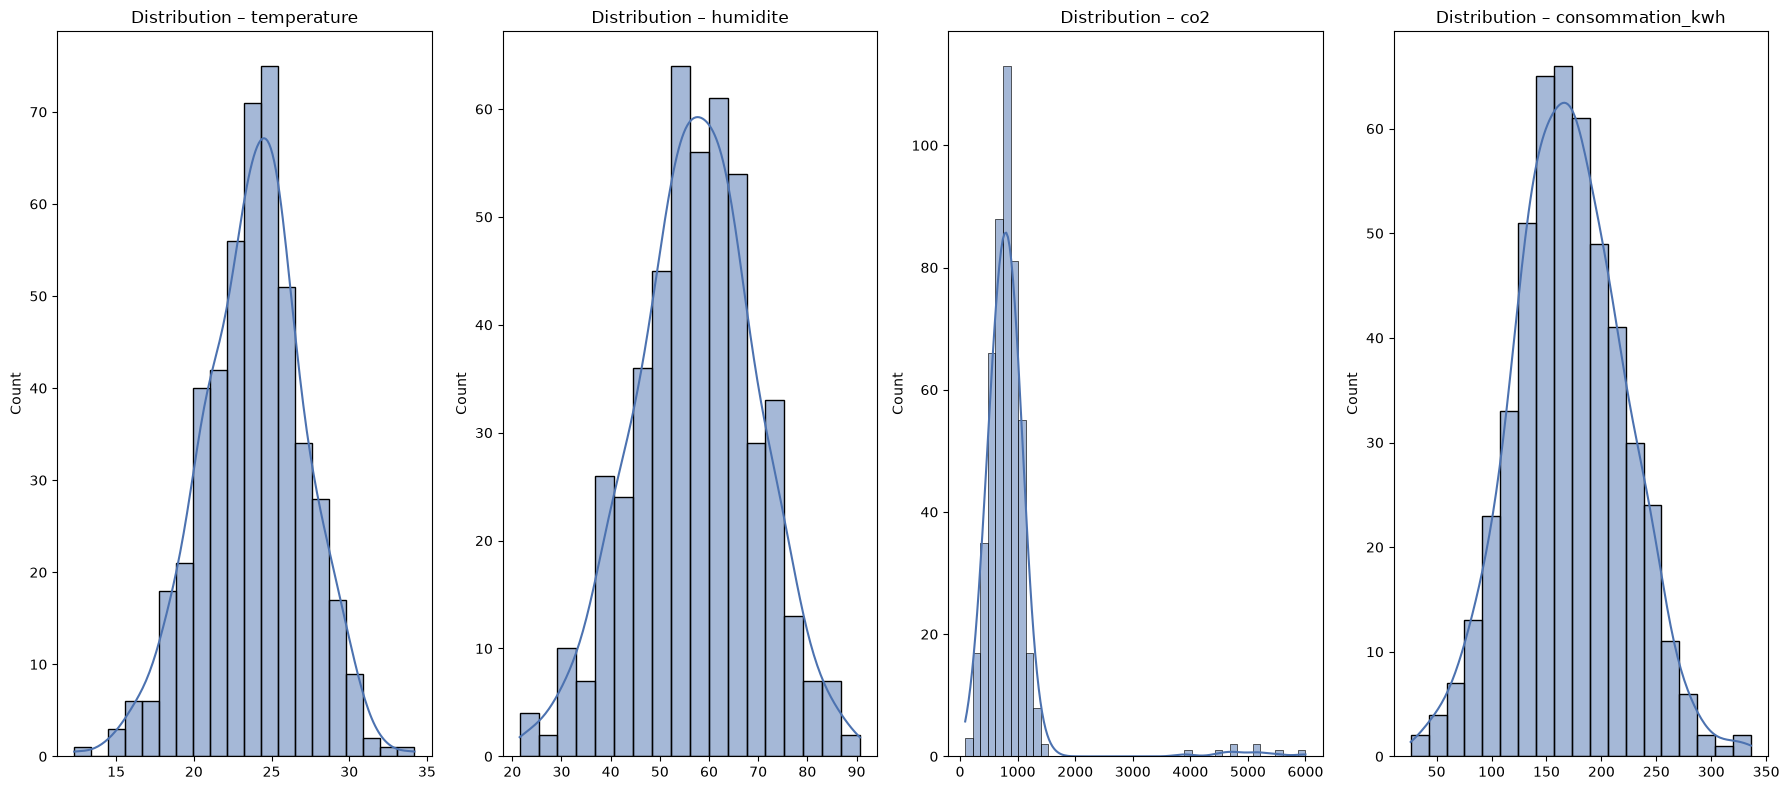

In [75]:
variables_cibles = ["temperature", "humidite", "co2", "consommation_kwh"]

fig, axes = plt.subplots(1, 4, figsize=(18, 8))

for i, col in enumerate(variables_cibles):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Distribution – {col}")
    axes[i].set_xlabel("")


plt.tight_layout()
plt.show()

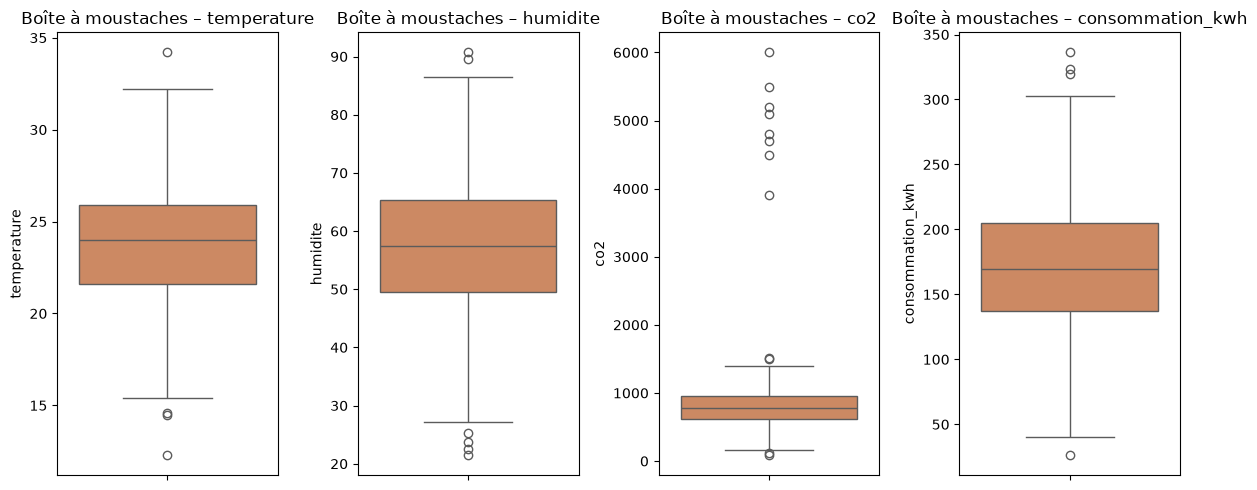

In [76]:
variables_cibles = ["temperature", "humidite", "co2", "consommation_kwh"]

fig, axes = plt.subplots(1, 4, figsize=(12, 5))

for i, col in enumerate(variables_cibles):

    sns.boxplot(y=df[col].dropna(), ax=axes[i], color="#DD8452")
    axes[i].set_title(f"Boîte à moustaches – {col}")

plt.tight_layout()
plt.show()

### a) Les distributions (symétrique ou non)

Les variables température, humidité et consommation semblent symétriques, tandis que pour le CO2, on voit nettement qu'il présente une asymétrie à droite.

### b) La dispersion

 Le CO2 présente la dispersion la plus marquée (écart-type / IQR) en raison de quelques valeurs particulièrement élevées. À l'inverse, les autres variables affichent une plus grande concentration autour de leur médiane.

### c) Les valeurs extrêmes


 Le diagramme en boîte met en évidence plusieurs valeurs aberrantes au-delà des moustaches, un phénomène particulièrement visible pour la variable CO2 qui présente quelques mesures très supérieures au reste de la distribution. Ces points devront être évalués en vue d'un traitement spécifique en tant qu'outliers lors du nettoyage des données.

### d) les valeurs potentiellement aberrantes


Ces valeurs extrêmes sont **plausibles physiquement** (contrairement aux valeurs impossibles
traitées à la question 12) : ce sont des situations rares, pas des erreurs de saisie.

## 16) Quelle stratégie utiliser pour les valeurs aberrantes ?


Il faut distinguer deux cas :

1. **Valeurs impossibles** (humidité > 100 %, consommation négative, température de 96 °C) :
   ce sont des erreurs. Elles ont déjà été transformées en `NaN` à la question 12-f, puis
   seront imputées.
2. **Valeurs extrêmes mais plausibles** (pics de CO₂, forte consommation) : elles portent de
   l'information, en particulier pour détecter les situations anormales — qui sont précisément
   l'objectif du projet. Les supprimer reviendrait à effacer les cas que le modèle doit apprendre
   à reconnaître.

**Stratégie retenue** : ne pas supprimer ces observations, mais limiter leur influence :

- imputation par la **médiane** (robuste aux valeurs extrêmes) ;

## 17) Afficher la fréquence des :

### a) bâtiments ;


<Axes: xlabel='batiment'>

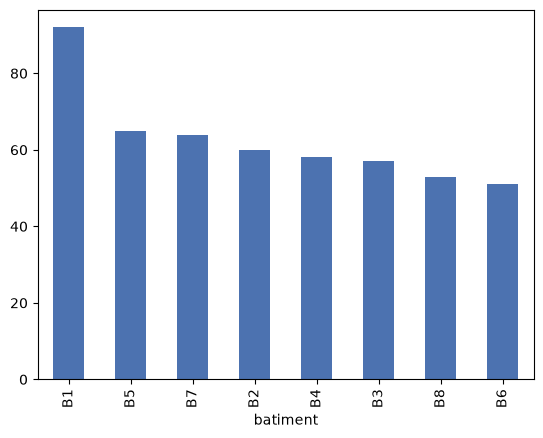

In [80]:
df["batiment"].value_counts().plot(kind="bar", color="#4C72B0")